In [1]:
import time
t1 = time.time()

import math
import os
import numpy as np
import pandas as pd
import h5py
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

import tensorflow as tf
import tensorflow.keras as keras
from tensorflow.keras import layers, models
from tensorflow.keras.optimizers import Adam , SGD , Adagrad
from tensorflow.keras.callbacks import ModelCheckpoint, LearningRateScheduler, EarlyStopping, CSVLogger, ReduceLROnPlateau
from tensorflow.keras.utils import to_categorical, plot_model
from tensorflow.keras import regularizers , initializers
from sklearn.metrics import confusion_matrix
import tensorflow.keras.backend as K
from sklearn import metrics
from sklearn.utils import shuffle
from sklearn.model_selection import train_test_split

gpus = tf.config.experimental.list_physical_devices("GPU")
tf.config.set_visible_devices(gpus[1], "GPU")

### set seed ###
keras.utils.set_random_seed(2330)
tf.config.experimental.enable_op_determinism()

2026-05-06 02:41:56.443213: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
##### load data #####

hhvv_HLdata_path = "/root/data/mucollider/two_boosted/10TeV/scan_kappa3_hhvv_HL.h5"
hhvv_HLdata_file = h5py.File(hhvv_HLdata_path, 'r')
print(hhvv_HLdata_file.keys())

hhvv_LLdata_path = "/root/data/mucollider/two_boosted/10TeV/scan_kappa3_hhvv_LL.h5"
hhvv_LLdata_file = h5py.File(hhvv_LLdata_path, 'r')
print(hhvv_LLdata_file.keys())

hhmumu_HLdata_path = "/root/data/mucollider/two_boosted/10TeV/scan_kappa3_hhmumu_HL.h5"
hhmumu_HLdata_file = h5py.File(hhmumu_HLdata_path, 'r')
print(hhmumu_HLdata_file.keys())

hhmumu_LLdata_path = "/root/data/mucollider/two_boosted/10TeV/scan_kappa3_hhmumu_LL.h5"
hhmumu_LLdata_file = h5py.File(hhmumu_LLdata_path, 'r')
print(hhmumu_LLdata_file.keys())

HLdata_path = "/root/data/mucollider/two_boosted/10TeV/data_HLfeature.h5"
HLdata_file = h5py.File(HLdata_path, 'r')
print(HLdata_file.keys())

LLdata_path = "/root/data/mucollider/two_boosted/10TeV/data_LLfeature.h5"
LLdata_file = h5py.File(LLdata_path, 'r')
print(LLdata_file.keys())

<KeysViewHDF5 ['BTag_leading', 'BTag_subleading', 'H_0', 'H_1', 'LB_1', 'M_JJ', 'S_0', 'S_1', 'X_HH', 'dEta_JJ', 'm_J_leading', 'm_J_subleading', 'missET', 'pT_JJ', 'pt_J_leading', 'pt_J_subleading', 'target_kappa_3']>
<KeysViewHDF5 ['particle_info']>
<KeysViewHDF5 ['BTag_leading', 'BTag_subleading', 'H_0', 'H_1', 'LB_1', 'M_JJ', 'S_0', 'S_1', 'X_HH', 'dEta_JJ', 'm_J_leading', 'm_J_subleading', 'missET', 'pT_JJ', 'pt_J_leading', 'pt_J_subleading', 'target_kappa_3']>
<KeysViewHDF5 ['particle_info']>
<KeysViewHDF5 ['BTag_leading', 'BTag_subleading', 'H_0', 'H_1', 'LB_1', 'M_JJ', 'S_0', 'S_1', 'X_HH', 'dEta_JJ', 'm_J_leading', 'm_J_subleading', 'missET', 'pT_JJ', 'pt_J_leading', 'pt_J_subleading', 'target_everytype', 'target_sigbg']>
<KeysViewHDF5 ['particle_info']>


In [3]:
##### include data #####

HLfeatures = ['BTag_leading', 'BTag_subleading', 'H_0', 'H_1', 'LB_1', 'M_JJ', 'S_0', 'S_1', 'X_HH', 'dEta_JJ', 'm_J_leading', 'm_J_subleading', 'missET', 'pT_JJ', 'pt_J_leading', 'pt_J_subleading']
LLfeatures = ['particle_info']

where_BG = np.where(HLdata_file['target_sigbg'][:]==0)

kappa3_val = 1.0
hhvv_where_kappa3 = np.where(hhvv_HLdata_file['target_kappa_3'][:]==kappa3_val)
hhmumu_where_kappa3 = np.where(hhmumu_HLdata_file['target_kappa_3'][:]==kappa3_val)

##### select BTag work point at WP70 (BitNumber 1) #####

BG_BTag_leading = ((HLdata_file['BTag_leading'][:][where_BG])&2)
BG_BTag_subleading = ((HLdata_file['BTag_subleading'][:][where_BG])&2)

##### include Signal data #####

hhvv_BTag_leading = ((hhvv_HLdata_file['BTag_leading'][:][hhvv_where_kappa3])&2)
hhvv_BTag_subleading = ((hhvv_HLdata_file['BTag_subleading'][:][hhvv_where_kappa3])&2)
hhmumu_BTag_leading = ((hhmumu_HLdata_file['BTag_leading'][:][hhmumu_where_kappa3])&2)
hhmumu_BTag_subleading = ((hhmumu_HLdata_file['BTag_subleading'][:][hhmumu_where_kappa3])&2)

hhvv_HLdata = []
for feature in HLfeatures:
    if feature=='BTag_leading': hhvv_HLdata.append(hhvv_BTag_leading)
    elif feature=='BTag_subleading': hhvv_HLdata.append(hhvv_BTag_subleading)
    else: hhvv_HLdata.append(hhvv_HLdata_file[feature][:][hhvv_where_kappa3])
hhvv_HLdata = np.array(hhvv_HLdata).T
print('shape of hhvv high level data:', hhvv_HLdata.shape)

hhvv_LLdata = hhvv_LLdata_file['particle_info'][:][hhvv_where_kappa3]
print('shape of hhvv low level data:', hhvv_LLdata.shape)

hhvv_target = np.ones(len(hhvv_where_kappa3[0]))
print('shape of hhvv target:', hhvv_target.shape)

hhmumu_HLdata = []
for feature in HLfeatures:
    if feature=='BTag_leading': hhmumu_HLdata.append(hhmumu_BTag_leading)
    elif feature=='BTag_subleading': hhmumu_HLdata.append(hhmumu_BTag_subleading)
    else: hhmumu_HLdata.append(hhmumu_HLdata_file[feature][:][hhmumu_where_kappa3])
hhmumu_HLdata = np.array(hhmumu_HLdata).T
print('shape of hhmumu high level data:', hhmumu_HLdata.shape)

hhmumu_LLdata = hhmumu_LLdata_file['particle_info'][:][hhmumu_where_kappa3]
print('shape of hhmumu low level data:', hhmumu_LLdata.shape)

hhmumu_target = np.ones(len(hhmumu_where_kappa3[0]))
print('shape of hhmumu target:', hhmumu_target.shape)

##### include Background data #####

BG_HLdata = []
for feature in HLfeatures:
    if feature=='BTag_leading': BG_HLdata.append(BG_BTag_leading)
    elif feature=='BTag_subleading': BG_HLdata.append(BG_BTag_subleading)
    else: BG_HLdata.append(HLdata_file[feature][:][where_BG])
BG_HLdata = np.array(BG_HLdata).T
print('shape of BG high level data:', BG_HLdata.shape)

BG_LLdata = LLdata_file['particle_info'][:][where_BG]
print('shape of BG low level data:', BG_LLdata.shape)

BG_target = HLdata_file['target_sigbg'][:][where_BG]
print('shape of BG target:', BG_target.shape)

##### merge the data #####

HLdata = np.concatenate((hhvv_HLdata, hhmumu_HLdata, BG_HLdata))
LLdata = np.concatenate((hhvv_LLdata, hhmumu_LLdata, BG_LLdata))
target = np.concatenate((hhvv_target, hhmumu_target, BG_target))

#### Do training data and validation data split #####

HL_train, HL_val, LL_train, LL_val, y_train, y_val = train_test_split(HLdata, LLdata, target, test_size=0.25, random_state=2330, shuffle=True)
print("\nAfter training validation data split:")
print("HL training data: ", HL_train.shape, "HL validation data: ", HL_val.shape)
print("LL training data: ", LL_train.shape, "LL validation data: ", LL_val.shape)
print("training target: ", y_train.shape, "validation target: ", y_val.shape)

shape of hhvv high level data: (22742, 16)
shape of hhvv low level data: (22742, 160)
shape of hhvv target: (22742,)
shape of hhmumu high level data: (24391, 16)
shape of hhmumu low level data: (24391, 160)
shape of hhmumu target: (24391,)
shape of BG high level data: (239264, 16)
shape of BG low level data: (239264, 160)
shape of BG target: (239264,)

After training validation data split:
HL training data:  (214797, 16) HL validation data:  (71600, 16)
LL training data:  (214797, 160) LL validation data:  (71600, 160)
training target:  (214797,) validation target:  (71600,)


In [4]:
where_BG

(array([     0,      1,      2, ..., 239261, 239262, 239263]),)

In [5]:
##### construct model #####

### high level features part ###

HL_input = layers.Input(shape=(16,), name='HL_Input')

x_hl = layers.Dense(128)(HL_input)
x_hl = layers.BatchNormalization()(x_hl)
x_hl = layers.Activation('relu')(x_hl)
x_hl = layers.Dropout(0.1)(x_hl)

x_hl = layers.Dense(128)(x_hl)
x_hl = layers.BatchNormalization()(x_hl)
x_hl = layers.Activation('relu')(x_hl)
x_hl = layers.Dropout(0.1)(x_hl)

### low level features part ###

LL_input = layers.Input(shape=(160,), name='LL_Input')

x_ll = layers.Dense(512)(LL_input)
x_ll = layers.BatchNormalization()(x_ll)
x_ll = layers.Activation('relu')(x_ll)
x_ll = layers.Dropout(0.1)(x_ll)

x_ll = layers.Dense(128)(x_ll)
x_ll = layers.BatchNormalization()(x_ll)
x_ll = layers.Activation('relu')(x_ll)
x_ll = layers.Dropout(0.1)(x_ll)

### combine two parts of model and the following node ###

combined = layers.Concatenate()([x_hl, x_ll])

x = layers.Dense(256, activation='relu')(combined)
x = layers.Dense(16, activation='relu')(x)
output = layers.Dense(1, activation='sigmoid', name='Output')(x)

model = models.Model(inputs=[HL_input, LL_input], outputs=output)

### optimizer ###

opt = keras.optimizers.Adam(learning_rate=1e-5)

### compile ###

model.compile(loss='binary_crossentropy', optimizer=opt, metrics=["accuracy","mse"])

### summary ###

model.summary()

2026-05-06 02:42:00.511027: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1639] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 46696 MB memory:  -> device: 1, name: NVIDIA RTX A6000, pci bus id: 0000:25:00.0, compute capability: 8.6


Model: "model"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 HL_Input (InputLayer)       [(None, 16)]                 0         []                            
                                                                                                  
 LL_Input (InputLayer)       [(None, 160)]                0         []                            
                                                                                                  
 dense (Dense)               (None, 128)                  2176      ['HL_Input[0][0]']            
                                                                                                  
 dense_2 (Dense)             (None, 512)                  82432     ['LL_Input[0][0]']            
                                                                                              

In [6]:
##### training model #####

tr_model = model.fit(x=[HL_train, LL_train], y=y_train, validation_data=([HL_val, LL_val], y_val), epochs=160, batch_size=256, verbose=1)

Epoch 1/160


2026-05-06 02:42:05.486915: I tensorflow/compiler/xla/stream_executor/cuda/cuda_blas.cc:606] TensorFloat-32 will be used for the matrix multiplication. This will only be logged once.
2026-05-06 02:42:05.499975: I tensorflow/compiler/xla/service/service.cc:168] XLA service 0x7f39500054a0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-05-06 02:42:05.500138: I tensorflow/compiler/xla/service/service.cc:176]   StreamExecutor device (0): NVIDIA RTX A6000, Compute Capability 8.6
2026-05-06 02:42:05.508725: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:255] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-05-06 02:42:05.711425: I tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:432] Loaded cuDNN version 8600
2026-05-06 02:42:05.851798: I ./tensorflow/compiler/jit/device_compiler.h:186] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.

840/840 [==============================] - 17s 12ms/step - loss: 0.3991 - accuracy: 0.8376 - mse: 0.1238 - val_loss: 0.3680 - val_accuracy: 0.8494 - val_mse: 0.1129
Epoch 2/160
840/840 [==============================] - 9s 10ms/step - loss: 0.3533 - accuracy: 0.8533 - mse: 0.1083 - val_loss: 0.3259 - val_accuracy: 0.8700 - val_mse: 0.0981
Epoch 3/160
840/840 [==============================] - 9s 11ms/step - loss: 0.3046 - accuracy: 0.8761 - mse: 0.0916 - val_loss: 0.2670 - val_accuracy: 0.8922 - val_mse: 0.0788
Epoch 4/160
840/840 [==============================] - 10s 12ms/step - loss: 0.2724 - accuracy: 0.8906 - mse: 0.0811 - val_loss: 0.2447 - val_accuracy: 0.9016 - val_mse: 0.0724
Epoch 5/160
840/840 [==============================] - 10s 12ms/step - loss: 0.2622 - accuracy: 0.8948 - mse: 0.0780 - val_loss: 0.2381 - val_accuracy: 0.9045 - val_mse: 0.0704
Epoch 6/160
840/840 [==============================] - 11s 13ms/step - loss: 0.2577 - accuracy: 0.8969 - mse: 0.0765 - val_loss: 

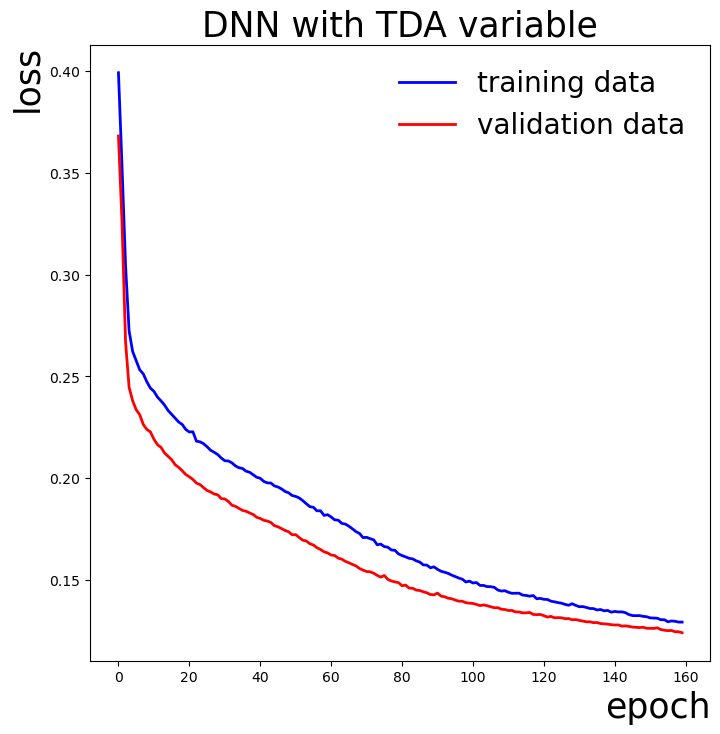

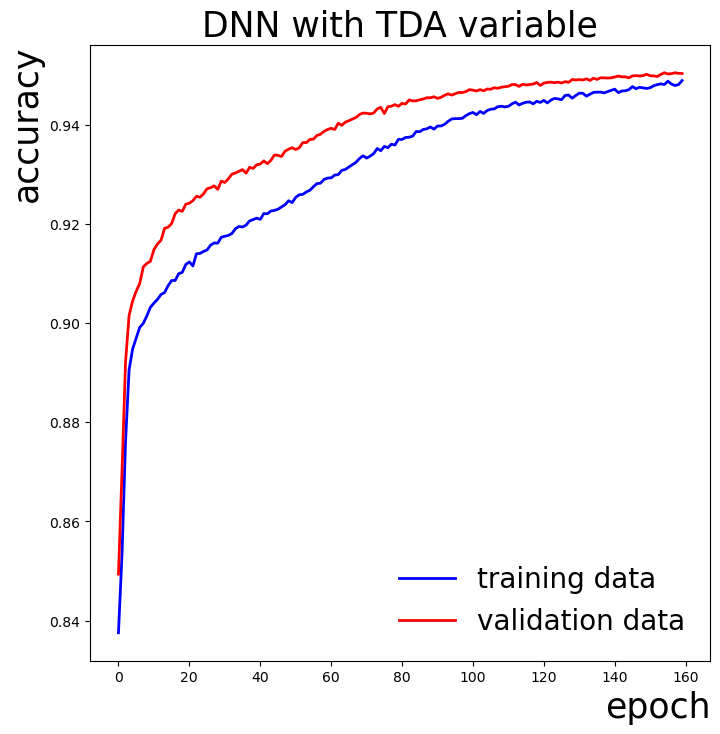

In [7]:
### plot learning curve

fig, ax = plt.subplots(1,1, figsize=(8,8))
plt.plot(tr_model.history["loss"], label='training data',c='blue',linewidth = 2)
plt.plot(tr_model.history["val_loss"], label='validation data',c='red',linewidth = 2)
plt.title("DNN with TDA variable", fontsize=25)
ax.set_ylabel('loss', fontsize=25,horizontalalignment='right',y=1)
ax.set_xlabel('epoch', fontsize=25,horizontalalignment='right',x=1)
# plt.yscale("log")
plt.legend(loc='best', prop={'size':20}, edgecolor = "w",fancybox=False, framealpha=0)
plt.show()

fig, ax = plt.subplots(1,1, figsize=(8,8))
plt.plot(tr_model.history["accuracy"], label='training data',c='blue',linewidth = 2)
plt.plot(tr_model.history["val_accuracy"], label='validation data',c='red',linewidth = 2)
plt.title("DNN with TDA variable", fontsize=25)
ax.set_ylabel('accuracy', fontsize=25,horizontalalignment='right',y=1)
ax.set_xlabel('epoch', fontsize=25,horizontalalignment='right',x=1)
# plt.yscale("log")
plt.legend(loc='best', prop={'size':20}, edgecolor = "w",fancybox=False, framealpha=0)
plt.show()

In [8]:
print("Time:{:^8.4f}(s)".format(time.time()-t1))

Time:1370.7848(s)


In [9]:
### save the model ###

model.save("/root/data/mucollider/two_boosted/10TeV/ML_model/model_mucollider_10.h5")

/root/miniconda3/envs/tf/lib/python3.10/site-packages/keras/src/engine/training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


high level influence:  0.05564999
low  level influence:  0.05399284


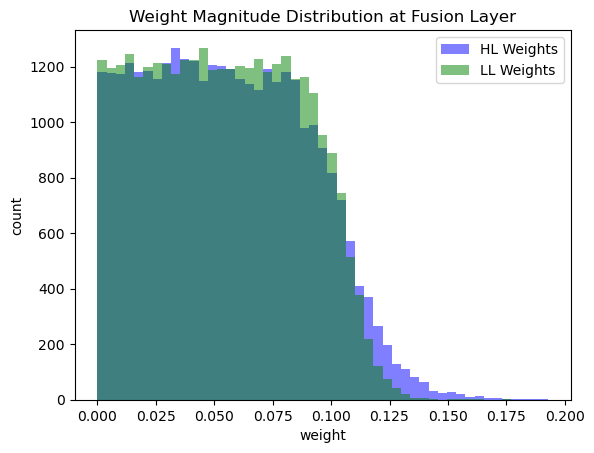

In [10]:
### check which part of model is more important ###

weights, biases = model.get_layer('dense_4').get_weights()
hl_influence = np.mean(np.abs(weights[:128, :]))
ll_influence = np.mean(np.abs(weights[128:, :]))
print("high level influence: ", hl_influence)
print("low  level influence: ", ll_influence)

weights, _ = model.get_layer('dense_4').get_weights()

hl_weights = np.abs(weights[:128, :]).flatten()
ll_weights = np.abs(weights[128:, :]).flatten()

bins = np.linspace(0,max(hl_weights), 50)
plt.hist(hl_weights, bins=bins, alpha=0.5, label='HL Weights', color='blue')
plt.hist(ll_weights, bins=bins, alpha=0.5, label='LL Weights', color='green')
plt.title('Weight Magnitude Distribution at Fusion Layer')
plt.xlabel('weight')
plt.ylabel('count')
plt.legend()
plt.show()

In [11]:
print("Time:{:^8.4f}(s)".format(time.time()-t1))

Time:1371.2144(s)
